In [1]:
import sys
import os

# Adjust the path to where the src folder is located
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from language_models.dictionary_corpus import Dictionary
from collections import defaultdict
import torch.nn as nn
from torch.nn.functional import scaled_dot_product_attention
import language_models.model as m
import math
import torch.nn.functional as F

In [3]:
device = torch.device('cpu')

In [4]:
class CBR_RNN(nn.Module):
    # goal here is to reuse CBR_RNN but with scaled dot product attention for more efficient computations.
    # Also I got rid of options such as loading pretrained embeddings, and ablating attention to simplify the code.
    # In the future if those options are needed, they can still be copy pasted from William's code as the structure hasn't changed
    def __init__(self, ntoken, ninp, nhid, nheads, dropout=0.5, device=None):
        super().__init__()
        # same layers as Timkey
        self.device = device
        self.nheads = nheads
        self.tanh = nn.Tanh()
        self.drop = nn.Dropout(dropout)
        self.score_attn = nn.Softmax(dim=-1)
        self.encoder = nn.Embedding(ntoken, ninp)
        self.q = nn.Linear(ninp + nhid, nhid)
        self.intermediate_h = nn.Linear(nhid * 4, nhid * 4)
        self.decoder = nn.Linear(nhid, ntoken)
        self.q_norm = torch.nn.LayerNorm(nhid)
        self.int_norm = torch.nn.LayerNorm(nhid * 4)
        self.f_norm = torch.nn.LayerNorm(nhid * 3)
        self.nhid = nhid
        self.final_h = nn.Linear(nhid * 4, nhid * 3)
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=nhid, num_heads=nheads, batch_first=True
        )

        self.init_weights()

    def init_weights(self):
        """Initialize model weights for better training dynamics"""
        # General initialization
        for name, param in self.named_parameters():
            if "weight" in name:
                if "norm" in name:
                    nn.init.ones_(param)
                elif "encoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                elif "decoder" in name:
                    nn.init.normal_(param, mean=0, std=0.01)
                else:
                    # Standard He initialization for processing layers
                    nn.init.kaiming_normal_(param, mode="fan_in", nonlinearity="tanh")
            elif "bias" in name:
                nn.init.zeros_(param)

    def init_cache(self, observation, nheads):
        """Initialize hidden state and attention caches with better initialization strategy"""
        if len(observation.size()) > 1:
            bsz = observation.size(dim=-1)
        else:
            bsz = 1

        hidden = torch.zeros(1, bsz, self.nhid).to(self.device) 
        if nheads == 1:
            key_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, 1, self.nhid).to(self.device) 
        else:
            key_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
            value_cache = torch.zeros(bsz, 1, self.nhid).to(self.device) 
        return hidden, key_cache, value_cache


    def update_cache(self, key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads):
        hidden_i = hidden_i.unsqueeze(0)
        hidden = torch.cat((hidden, hidden_i), dim=0)
        if nheads == 1:
                key_cache_i = key_cache_i.unsqueeze(1).unsqueeze(1)
                value_cache_i = value_cache_i.unsqueeze(1).unsqueeze(1)
                key_cache = torch.cat((key_cache, key_cache_i), dim=2)
                value_cache = torch.cat((value_cache, value_cache_i), dim=2)
        else:
            key_cache_i = key_cache_i.unsqueeze(1)
            value_cache_i = value_cache_i.unsqueeze(1)
            key_cache = torch.cat((key_cache, key_cache_i), dim=1)
            value_cache = torch.cat((value_cache, value_cache_i), dim=1)
            
        return key_cache, value_cache, hidden
    
    @staticmethod
    def temperature_attention(query, key, value, temperature, gumbel_softmax=None, attn_mask=None,dropout_p=0.0,
        is_causal=False, scale=None, enable_gqa=False) -> torch.Tensor:
        L, S = query.size(-2), key.size(-2)
        scale_factor = 1 / math.sqrt(query.size(-1)) if scale is None else scale
        attn_bias = torch.zeros(L, S, dtype=query.dtype, device=query.device)
        if is_causal:
            assert attn_mask is None
            temp_mask = torch.ones(L, S, dtype=torch.bool).tril(diagonal=0)
            attn_bias.masked_fill_(temp_mask.logical_not(), float("-inf"))
            attn_bias.to(query.dtype)

        if attn_mask is not None:
            if attn_mask.dtype == torch.bool:
                attn_bias.masked_fill_(attn_mask.logical_not(), float("-inf"))
            else:
                attn_bias = attn_mask + attn_bias

        if enable_gqa:
            key = key.repeat_interleave(query.size(-3)//key.size(-3), -3)
            value = value.repeat_interleave(query.size(-3)//value.size(-3), -3)

        attn_weight = query @ key.transpose(-2, -1) * scale_factor
        attn_weight += attn_bias
        if gumbel_softmax: 
            attn_weight = torch.gumbel_softmax(attn_weight, tau=temperature, hard=False, dim=-1)
        else : 
            attn_weight = attn_weight/temperature
            attn_weight = torch.softmax(attn_weight, dim=-1)
        attn_weight = torch.dropout(attn_weight, dropout_p, train=True)
        return attn_weight, attn_weight @ value
    
    def attention_layer(self, query, key_cache, value_cache, nheads, temperature, gumbel_softmax):
        if nheads == 1:
                query = query.unsqueeze(1)
                
                # Ensure all tensors are on the same device
                if query.device != key_cache.device:
                    key_cache = key_cache.to(query.device)
                if query.device != value_cache.device:
                    value_cache = value_cache.to(query.device)
                if temperature==1:  
                    try:
                        attn_output = scaled_dot_product_attention(
                            query, key_cache, value_cache, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)
                else:
                    try:
                        attn_weight, attn_output = self.temperature_attention(
                            query, key_cache, value_cache, temperature, is_causal=False
                        )
                    except Exception as e:
                        logging.error(f"Error in attention computation: {str(e)}")
                        raise
                    attn = attn_output.squeeze(1).squeeze(1)
                    del attn_output  # No longer needed after squeezing
                    query = query.squeeze(1).squeeze(1)

            
        else:
            attn_output, _ = self.multihead_attn(
                query, key_cache, value_cache, is_causal=False
            )
            attn = attn_output.squeeze(1)
            del attn_output  # No longer needed after squeezing
            query = query.squeeze(1)
            
        return attn_weight, attn, query
    
    def intermediate_layers(self, i, emb, query, attn, hidden):
        intermediate_input = torch.cat((emb[i], query, attn, hidden[-1]), -1)
        del query, attn  
        intermediate = self.drop(
            self.tanh(self.int_norm(self.intermediate_h(intermediate_input)))
        )
        del intermediate_input  
        final_output = self.drop(self.tanh(self.f_norm(self.final_h(intermediate))))
        del intermediate  
        key_cache_i, value_cache_i, hidden_i = final_output.split(self.nhid, dim=-1)
        del final_output
        return key_cache_i, value_cache_i, hidden_i
    
    def get_query(self, emb, hidden):
        combined = torch.cat((emb, hidden[-1]), -1)
        query = self.drop(self.tanh(self.q_norm(self.q(combined))))
        del combined  # No longer needed after creating query
        query = query.unsqueeze(1)
        return query
    
    def forward(self, observation, initial_cache, nheads, temperature, gumbel_softmax):
        seq_len = observation.size(0)
        hidden, key_cache, value_cache = initial_cache

        # 1. Encode observations
        emb = self.drop(self.encoder(observation))
        del observation  # No longer needed after encoding
        attn_weights = []
        for i in range(seq_len):
            # 2. Concatenate with previous hidden state

            
            query = self.get_query(emb[i], hidden)
            
            attn_weight, attn, query = self.attention_layer(query, key_cache, value_cache, nheads, temperature, gumbel_softmax)
            attn_weights.append(attn_weight)
            key_cache_i, value_cache_i, hidden_i = self.intermediate_layers(i, emb, query, attn, hidden)
            
            key_cache, value_cache, hidden = self.update_cache(key_cache, value_cache, hidden, key_cache_i, value_cache_i, hidden_i, nheads)
            
            del key_cache_i, value_cache_i, hidden_i  # No longer needed after concatenation

        decoded = self.decoder(hidden[1:])

        return decoded, hidden, attn_weights

In [22]:
model = CBR_RNN(50001, 650, 650, 1, 0, device)
check = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/test_attention_650/epoch_38.pt', map_location='cpu')
model.load_state_dict(check['model_state_dict'])
temp = check['epoch']

In [23]:
class WMTestDataset(Dataset):
    def __init__(self, sentences_path, markers_path, dictionary):
        """
        sentences_path: path to the sentence file (one sentence per line)
        markers_path: path to marker file (CSV/TSV with columns: markers, stimid, list_len, prompt_len)
                      markers column contains array-like strings (e.g. '[0,0,1,1,...]')
        dictionary: object with attribute 'word2idx' (dict mapping words to indices), and
                    should contain an "<unk>" key for unknown words.
        """
        self.dictionary = dictionary
        
        # Load sentences
        with open(sentences_path, "r", encoding="utf-8") as f:
            self.sentences = [line.strip().split() for line in f if line.strip()]
        
        # Load markers metadata file with pandas
        self.markers_df = pd.read_csv(markers_path, sep="\t", converters={
            'markers': lambda x: list(map(int, x.strip('[]').split(',')))
        })
        
        # Sanity check: same number of sentences and markers rows
        assert len(self.sentences) == len(self.markers_df), \
            f"Mismatch: {len(self.sentences)} sentences vs {len(self.markers_df)} marker entries"
    
    def __len__(self):
        return len(self.sentences)
    
    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        row = self.markers_df.iloc[idx]
        
        markers = row['markers']
        stimid = row['stimid']
        list_len = row['list_len']
        prompt_len = row['prompt_len']
        
        encoded_sentence = [
            self.dictionary.word2idx.get(word, self.dictionary.word2idx.get("<unk>"))
            for word in sentence
        ]
        
        list1 = [sentence[i] for i, tag in enumerate(markers) if tag == 1]
        list2 = [sentence[i] for i, tag in enumerate(markers) if tag == 3]
        
        list1_encoded = [
        encoded_sentence[i] for i, tag in enumerate(markers) if tag == 1
        
        ]
        list2_encoded = [
            encoded_sentence[i] for i, tag in enumerate(markers) if tag == 3
        ]
        
        condition = (list_len, prompt_len)
        
        sample = {
            "sentence": sentence,              # list of tokens (words)
            "encoded_sentence": encoded_sentence, 
            'list1_encoded':list1_encoded,
            "list1":list1,
            "list2_encoded": list2_encoded,
            "list2":list2,
            "stimid": stimid,  
            "condition" : condition,
            "marker":markers
            # "list_len": list_len,              # int
            # "prompt_len": prompt_len           # int
        }
        return sample


In [66]:
sentence_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/categorized_lists_sce3_repeat.txt'
marker_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/categorized_lists_sce3_repeat_markers.txt'
data_path = "/scratch2/mrenaudin/colorlessgreenRNNs/english_data"
dictionary = Dictionary(data_path)
wm_dataset = WMTestDataset(sentence_path, marker_path, dictionary)

In [25]:
sentence_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/categorized_lists_sce1_repeat.txt'
marker_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/categorized_lists_sce1_repeat_markers.txt'

# Read the first line of the sentence file
with open(sentence_path, 'r') as f:
    first_sentence_line = f.readline()

# Read the first two lines of the marker file (header + first data line)
with open(marker_path, 'r') as f:
    first_marker_lines = [f.readline(), f.readline()]

# Paths for new files containing just the selected lines
single_sentence_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/first_sentence.txt'
single_marker_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/first_two_marker_lines.txt'

# Write the single sentence line
with open(single_sentence_path, 'w') as f:
    f.write(first_sentence_line)

# Write the two marker lines
with open(single_marker_path, 'w') as f:
    f.writelines(first_marker_lines)

# Use these new files for your dataset



In [65]:
wm_dataset = WMTestDataset(single_sentence_path, single_marker_path, dictionary)

In [27]:
def collate_fn(batch):
    """Custom collate function to properly handle sentences as lists of strings."""
    sentences = [item["sentence"] for item in batch] 
    list1 = [item["list1"] for item in batch] 
    list2 = [item["list2"] for item in batch] 
    encoded_sentences = torch.stack([torch.tensor(item["encoded_sentence"]) for item in batch])  
    list1_encoded = torch.stack([torch.tensor(item["list1_encoded"]) for item in batch])
    list2_encoded = torch.stack([torch.tensor(item["list2_encoded"]) for item in batch])
    marker = torch.stack([torch.tensor(item['marker']) for item in batch])
    conditions = [item["condition"] for item in batch]

    return {
        "sentence": sentences,
        "encoded_sentence": encoded_sentences,
        "list1": list1,
        "list2": list2,
        "list1_encoded":list1_encoded,
        "list2_encoded":list2_encoded,
        "condition": conditions,
        "marker": marker
    }

In [67]:
dataloader = DataLoader(wm_dataset, batch_size=230, collate_fn=collate_fn)


In [124]:
from evaluation_notebooks.utils import NounPPDataset, collate_fn_nounpp
nounpp = '//scratch2/mrenaudin/colorlessgreenRNNs/NounPP/Stimuli/nounpp.txt'

dataset = NounPPDataset(nounpp, dictionary)
dataloader = DataLoader(dataset, batch_size=1000, collate_fn=collate_fn_nounpp)

/home/mrenaudin/.conda/envs/leaps3/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [125]:
def eval(model, dataloader):
    all_repeat_surprisals = {}
    model.eval()
    all_attention=[]
    # Forward pass with hidden state update word by word
    with torch.no_grad():
        for batch in dataloader:
            out = None
            list1 = batch["list1"]
            encoded_sentence = batch["encoded_sentence"]
            condition = batch["condition"]
            marker = batch["marker"]
            batch_size, seq_len = encoded_sentence.shape
            input_seq = encoded_sentence[:, :-1].transpose(0, 1)  # (seq_len-1, batch_size)
            target_seq = encoded_sentence[:, 1:].transpose(0, 1)
            cache = model.init_cache(input_seq, 1)
            output, hidden, attn_weights = model(input_seq, cache, 1, temp, True)
            all_attention.append(attn_weights)
        
            log_probs = F.log_softmax(output, dim=-1)  # shape (seq_len-1, batch_size, vocab_size)
            
            nll_loss = F.nll_loss(
                        log_probs.reshape(-1, log_probs.size(-1)),  # ( (seq_len-1)*batch_size, vocab_size )
                        target_seq.reshape(-1),                         # ((seq_len-1)*batch_size)
                        reduction='none'
                    )
                    
                    # Reshape back to (seq_len-1, batch_size)
            nll_loss = nll_loss.view(seq_len - 1, batch_size).transpose(0, 1)  # (batch_size, seq_len-1)        
            mask_list1 = (marker[:, 1:] == 1)  # remove first token since nll_loss aligns with shifted target
            mask_list2 = (marker[:, 1:] == 3)
            
            # Extract surprisal for each list and reshape
            # Number of tokens in each list should be condition[0][0]*2 (including punctuation)
            list_len = condition[0][0] * 2
            
            surprisal_list1 = nll_loss[mask_list1].view(batch_size, list_len)
            surprisal_list2 = nll_loss[mask_list2].view(batch_size, list_len)
            
            # Select repeated word indices (odd positions assuming repeats are at odd indices)
            word_indices = torch.arange(0, condition[0][0]*2, step=2)  # e.g., 1, 3, 5, ...
            word_indices = word_indices[1:]#get rid of first word of the list
            # print(word_indices)
            # for i in word_indices:
            #     words_at_indices = list1[0][i]
            #     print(words_at_indices)
            surprisal1_repeats = surprisal_list1[:, word_indices]
            surprisal2_repeats = surprisal_list2[:, word_indices]
            
            # Compute repeat surprisal ratio as percentage
            repeat_surprisal = (surprisal2_repeats / surprisal1_repeats) * 100
            all_repeat_surprisals[f'list len : {condition[0][0]}, prompt len : {condition[0][1]}']=repeat_surprisal
          
    return all_repeat_surprisals, all_attention, encoded_sentence
        

In [126]:
surprise, attention, encoded_sentence = eval(model, dataloader)

KeyError: 'list1'

In [109]:
len(attention)#nb batch

4

In [110]:
len(attention[0])#seq len

31

In [111]:
len(attention[0][0])#batch size

230

In [119]:
import torch

avg_attention_per_batch = []

for b in range(len(attention)):  # over batches
    seq_len = len(attention[b])  # max sequence length for this batch
    batch_size = len(attention[b][0])  # fixed across batches

    batch_matrices = []

    for i in range(batch_size):
        # Initialize zero matrix for this sample
        attn_matrix = torch.zeros(seq_len, seq_len)

        for t in range(seq_len):
            attn_vec = attention[b][t][i]  # shape: (t + 1,)
            attn_matrix[t, :t + 1] = torch.tensor(attn_vec)

        batch_matrices.append(attn_matrix)

    avg_attention_per_batch.append(batch_matrices)



/tmp/ipykernel_2677518/433849954.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attn_matrix[t, :t + 1] = torch.tensor(attn_vec)


In [120]:
batch_avg = torch.stack(avg_attention_per_batch[1]).mean(dim=0)  # (seq_len, seq_len)


In [121]:
batch_avg.shape

torch.Size([39, 39])

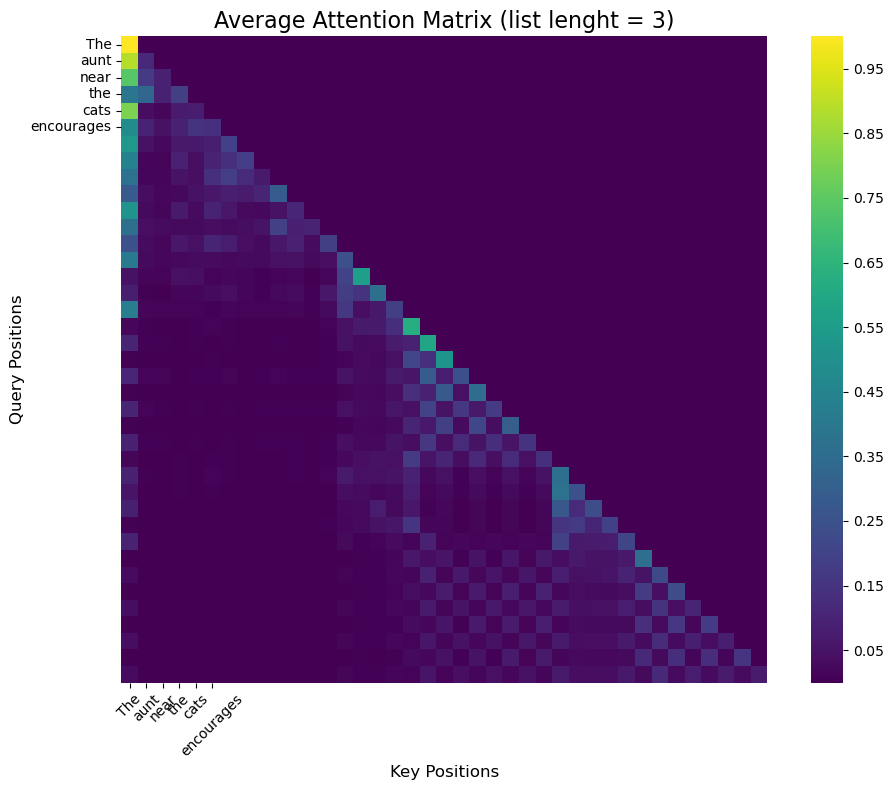

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors


# Example input sentence
sentence = "The aunt near the cats encourages".split()
seq_len = len(sentence)

num_bins = 10
bounds = np.linspace(batch_avg.min(), batch_avg.max(), num_bins + 1)
# Create a colormap with discrete colors from viridis
cmap = plt.get_cmap('viridis', num_bins)

# Create a norm to map attention values to the discrete bins
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=num_bins)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(batch_avg, 
            xticklabels=sentence, 
            yticklabels=sentence, 
            cmap='viridis', 
            cbar=True, 
            square=True)

cbar = plt.gcf().axes[-1]
tick_locs = (bounds[:-1] + bounds[1:]) / 2
cbar.set_yticks(tick_locs)
cbar.set_yticklabels([f"{b:.2f}" for b in tick_locs])

plt.title("Average Attention Matrix (list lenght = 3)", fontsize=16)
plt.xlabel("Key Positions", fontsize=12)
plt.ylabel("Query Positions", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [137]:
import sys
import os

sys.path.append('/scratch2/mrenaudin/colorlessgreenRNNs')

from evaluation_notebooks.utils import NounPPDataset, collate_fn_nounpp

nounpp = '//scratch2/mrenaudin/colorlessgreenRNNs/NounPP/Stimuli/nounpp.txt'

dataset = NounPPDataset(nounpp, dictionary)
dataloader = DataLoader(dataset, batch_size=1000, collate_fn=collate_fn_nounpp)

In [162]:
def eval_cbr_nounpp(model, test_dataloader):
    condition_accuracies = defaultdict(int)
    condition_counts = defaultdict(int)
    correct_pred = 0
    sentence_details = []
    model.eval()
    all_attention = []
    # Forward pass with hidden state update word by word
    with torch.no_grad():
        for batch in test_dataloader:
            out = None
            written = batch["sentence"]
            sentence = batch["encoded_sentence"]
            correct = batch["encoded_correct"]
            wrong = batch["encoded_wrong"]
            condition = batch["condition"]
            batch_size = sentence.size(0)

            sent = sentence.transpose(0, 1)
            cache = model.init_cache(sent,1)  # regarder si on peut mettre du priming
            # for i in range(sent.shape[1]):
            print(temp)
            out, hidden, attn_weights = model(sent, cache, 1, temp, True)
            all_attention.append(attn_weights)            
            log_probs = torch.nn.functional.log_softmax(
                out, dim=-1
            )  # s(out.squeeze(0))
            # déja sur correct et wrong log probs, pas les même résultats que sur extract_predictions.py
            correct_log_probs = log_probs[
                -1, torch.arange(batch_size), correct
            ]  # Shape: [512]
            wrong_log_probs = log_probs[-1, torch.arange(batch_size), wrong]
            correct_predictions = correct_log_probs >= wrong_log_probs

            for i in range(batch_size):
                cond = condition[i]
                pred = correct_predictions[i].item()  # Convert tensor to Python boolean
                condition_counts[cond] += 1
                condition_accuracies[cond] += pred

                sentence_details.append(
                    {
                        "sentence": written[i],
                        "condition": condition[i],
                        "correct_log_prob": correct_log_probs[i],
                        "wrong_log_prob": wrong_log_probs[i],
                        "model_prefers_correct": pred,
                    }
                )

    final_accuracies = {
        cond: condition_accuracies[cond] / condition_counts[cond]
        for cond in condition_accuracies
    }
    return final_accuracies, all_attention

In [163]:
acc, attn= eval_cbr_nounpp(model, dataloader)

0.1188502227437019
0.1188502227437019
0.1188502227437019
0.1188502227437019


In [165]:
import torch

avg_attn= []

for b in range(len(attn)):  # over batches
    seq_len = len(attn[b])#+1
    print(seq_len)# max sequence length for this batch
    batch_size = len(attn[b][0])  # fixed across batches

    batch_matrices = []

    for i in range(batch_size):
        # Initialize zero matrix for this sample
        attn_matrix = torch.zeros(seq_len, seq_len)
        print(attn_matrix.shape)
        for t in range(seq_len):
            attn_vec = attn[b][t][i]  # shape: (t + 1,)
            attn_matrix[t, :t + 1] = torch.tensor(attn_vec)

        batch_matrices.append(attn_matrix)
    print(len(batch_matrices))
    avg_attn.append(batch_matrices)
print(torch.stack(avg_attn[2]).shape)
batch_avg = torch.stack(avg_attn[2]).mean(dim=0)
print()

6
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size

/tmp/ipykernel_2677518/3269104436.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attn_matrix[t, :t + 1] = torch.tensor(attn_vec)


torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([6, 6])
torch.Size([

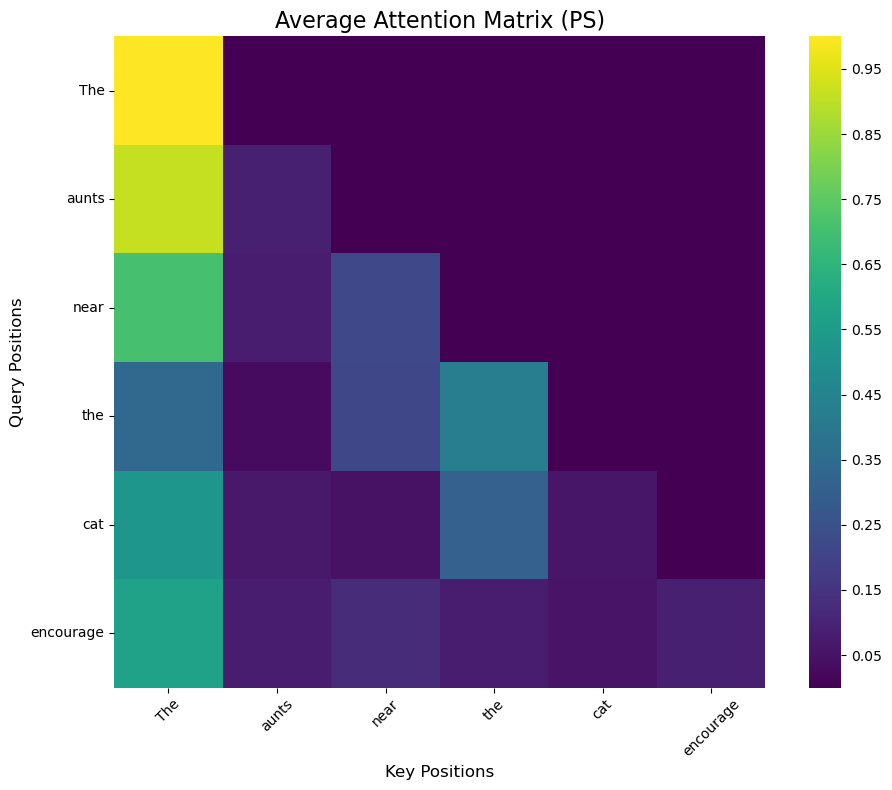

In [168]:
# Example input sentence
sentence = "The aunts near the cat encourage".split()
seq_len = len(sentence)

num_bins = 10
bounds = np.linspace(batch_avg.min(), batch_avg.max(), num_bins + 1)
# Create a colormap with discrete colors from viridis
cmap = plt.get_cmap('viridis', num_bins)

# Create a norm to map attention values to the discrete bins
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=num_bins)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(batch_avg, 
            xticklabels=sentence, 
            yticklabels=sentence, 
            cmap='viridis', 
            cbar=True, 
            square=True)

cbar = plt.gcf().axes[-1]
tick_locs = (bounds[:-1] + bounds[1:]) / 2
cbar.set_yticks(tick_locs)
cbar.set_yticklabels([f"{b:.2f}" for b in tick_locs])

plt.title("Average Attention Matrix (PS)", fontsize=16)
plt.xlabel("Key Positions", fontsize=12)
plt.ylabel("Query Positions", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [173]:
len(attn)

4

In [174]:
len(attn[0])

6

In [175]:
len(attn[0][0])

1000

torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size([1, 1, 5])
torch.Size([1, 1, 2])
torch.Size

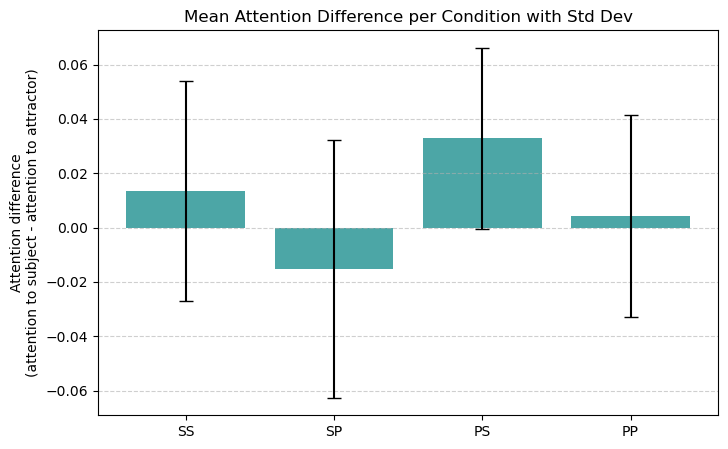

In [184]:
import numpy as np
import matplotlib.pyplot as plt

conditions = ['SS', 'SP', 'PS', 'PP']
diffs_per_condition = []

for batch_idx in range(len(attn)):
    batch_attention = attn[batch_idx]  # list of length seq_len, each element is list of batch_size
    
    seq_len = len(batch_attention)
    batch_size = len(batch_attention[0])
    
    diff_samples = []
    for sample_idx in range(batch_size):
        # Attention to token at position 2 (index 1)
        attn_token_2 = batch_attention[1][sample_idx]
        print(attn_token_2.shape)
        # Attention to token at position 5 (index 4)
        attn_token_5 = batch_attention[4][sample_idx]
        print(attn_token_5.shape)
        attn_token_2_scalar = attn_token_2[0, 0, -1].item()
        attn_token_5_scalar = attn_token_5[0, 0, -1].item()
        diff_samples.append(attn_token_2_scalar - attn_token_5_scalar)
    
    diffs_per_condition.append(diff_samples)

means = [np.mean(diffs) for diffs in diffs_per_condition]
stds = [np.std(diffs) for diffs in diffs_per_condition]

plt.figure(figsize=(8, 5))
x_pos = np.arange(len(conditions))
plt.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, color='teal')
plt.xticks(x_pos, conditions)
plt.ylabel("Attention difference\n(attention to subject - attention to attractor)")
plt.title("Mean Attention Difference per Condition with Std Dev")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
